# Week11 - Part2: Image Retrieval using KD-Tree


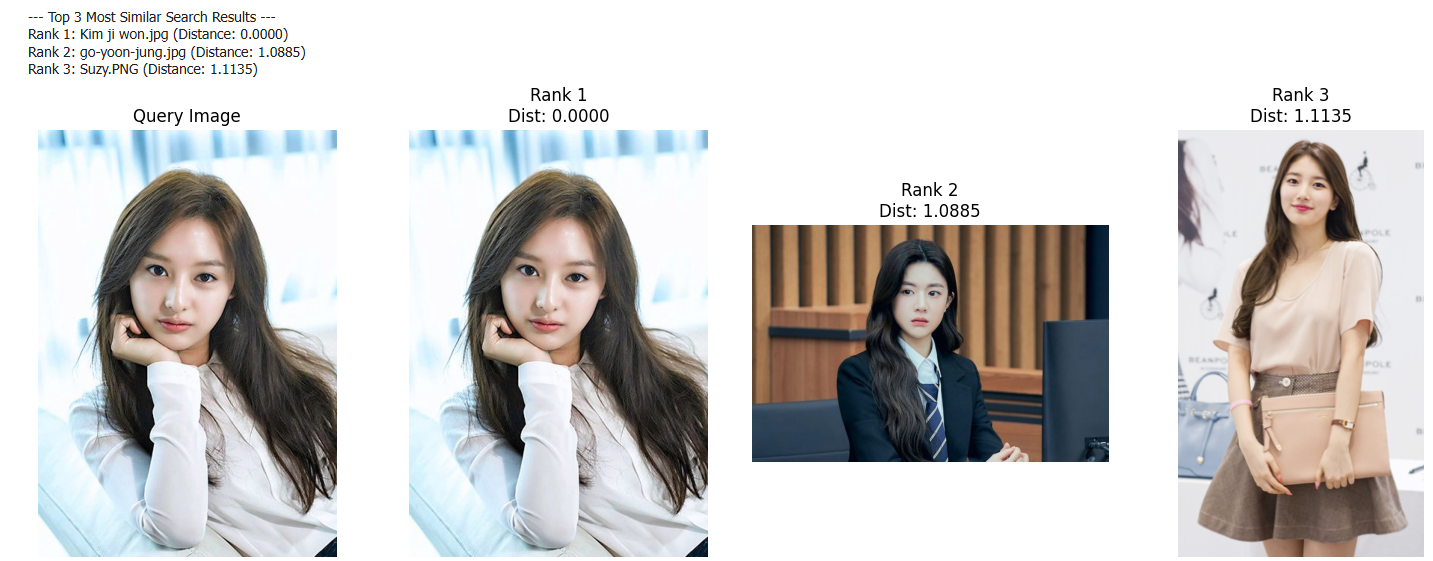


In [1]:
import os
import numpy as np
from sklearn.neighbors import KDTree
from pathlib import Path
import sys
from PIL import Image
import matplotlib.pyplot as pltimport

In [2]:
# System path 
sys.path.append(r'C:\Users\jinny\Desktop\cv\Face')
from face_extraction import *

['Chae-Soo-Bin.jpg', 'go-yoon-jung.jpg', 'Han_Sohee.jpg', 'Hyun-Bin.jpg', 'Ji_Chang-Wook.jpeg', 'Kim ji won.jpg', 'Kim Soo-hyun.jpg', 'Kim woo-bin.jpg', 'kim-seon-ho.jpg', 'Lee Dong-wook.jpg', 'lee-jung-jae.jpg', 'lee-min-ho.jpg', 'Lee_se_young.jpg', 'Park Bogum.jpg', 'Park eun bin.jpg', 'Park Seo-joon.jpg', 'parkboyoung.jpg', 'Son Ye Jin.jpg', 'Song Hye Kyo.jpg', 'Suzy.PNG']
Extracting embeddings...
C:\Users\jinny\Desktop\cv\Face/Chae-Soo-Bin.jpg
C:\Users\jinny\Desktop\cv\Face/go-yoon-jung.jpg
C:\Users\jinny\Desktop\cv\Face/Han_Sohee.jpg
C:\Users\jinny\Desktop\cv\Face/Hyun-Bin.jpg
C:\Users\jinny\Desktop\cv\Face/Ji_Chang-Wook.jpeg
C:\Users\jinny\Desktop\cv\Face/Kim ji won.jpg
C:\Users\jinny\Desktop\cv\Face/Kim Soo-hyun.jpg
C:\Users\jinny\Desktop\cv\Face/Kim woo-bin.jpg
C:\Users\jinny\Desktop\cv\Face/kim-seon-ho.jpg
C:\Users\jinny\Desktop\cv\Face/Lee Dong-wook.jpg
C:\Users\jinny\Desktop\cv\Face/lee-jung-jae.jpg
C:\Users\jinny\Desktop\cv\Face/lee-min-ho.jpg
C:\Users\jinny\Desktop\cv\Face

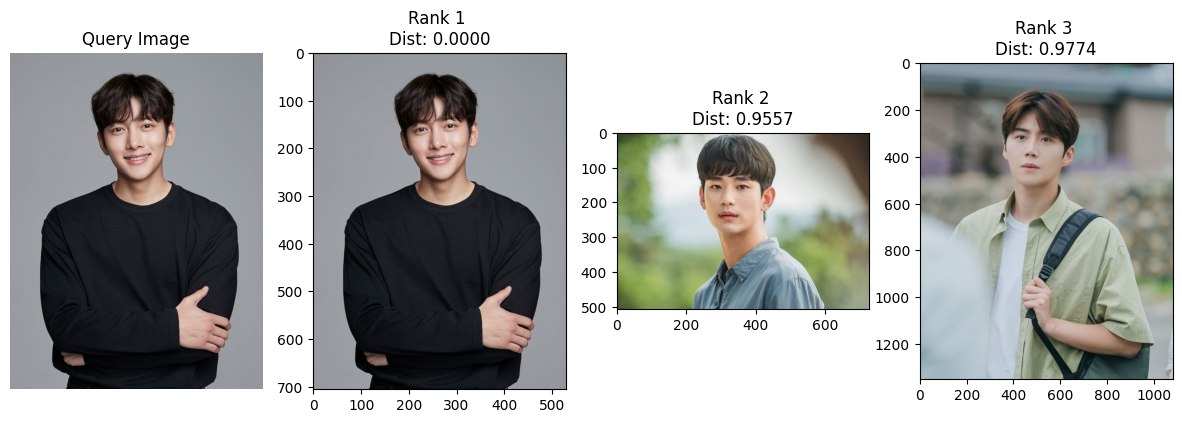

display images


In [3]:
# --------------------------------------------
# Step 1: Define the folder containing face images (Database)
# --------------------------------------------
database_folder = r'C:\Users\jinny\Desktop\cv\Face'

# Change this path to your own dataset folder

# Check whether the folder exists
if not os.path.exists(database_folder):
    print(f"Please add face images to the folder: {database_folder}")
else:

    # --------------------------------------------
    # Step 2: Load known face encodings from database
    # --------------------------------------------
    know_encodings, know_images, know_names = face_extraction(database_folder)
    # If no faces are detected in the database
    if len(know_encodings) == 0:
        print("No faces detected in the database folder.")
    else:
        # --------------------------------------------
        # Step 3: Build KD-Tree for fast nearest neighbor search
        # --------------------------------------------
        tree = KDTree(know_encodings)

        # --------------------------------------------
        # Step 4: Provide a query image for searching
        # --------------------------------------------
        test_image_path = r'C:\Users\jinny\Desktop\cv\Face\Ji_Chang-Wook.jpeg'  # Change this to your query image path

        # Extract face encoding from the query image
        test_encoding, query_image = query_extraction(
            member_path = test_image_path
        )

        # If a face is detected in the query image
        if len(test_encoding) > 0:
            # --------------------------------------------
            # Step 5: Find Top-3 most similar faces (k=3)
            # dist  -> distance (smaller value = more similar)
            # ind   -> index of matched face in database
            # --------------------------------------------
            dist, ind = tree.query([test_encoding[0]], k=3)
            print("\nTop-3 Most similar Search Results...")
            for i in range(len(ind[0])):
                index = ind[0][i]
                destance = dist[0][i]
                # Smaller distance means higher similarity
                print(f"Rank {i+1}: {know_names[index]} \ Distance: {destance:.4f}")

            # --------------------------------------------
            # Step 6: Display query image and matched results
            # --------------------------------------------
            display_result(query_image, know_images, ind, dist)

   

